# Bengaluru House Price Regression — Fully Connected Network

A Dense network that predicts `price` (in lakhs of rupees) from the listing attributes of the
Bengaluru property dataset.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print('TensorFlow: ', tf.__version__)
print('Keras', keras.__version__)

TensorFlow:  2.21.0
Keras 3.15.1


In [2]:
house_data = pd.read_csv('../bengaluru_house_prices.csv')

print('shape: ', house_data.shape)
house_data.head()

shape:  (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [4]:
missing_share = house_data.isna().mean().mul(100).round(2)
missing_share[missing_share > 0]

location     0.01
size         0.12
society     41.31
bath         0.55
balcony      4.57
dtype: float64

## Cleaning the listings

`total_sqft` is stored as text: most rows are plain numbers, 201 are ranges such as
`"1000 - 1200"`, and 46 carry a non-imperial unit (`Sq. Meter`, `Acres`, `Guntha`, …). Ranges
collapse to their midpoint and the unit-bearing values are converted to square feet, which
keeps the column continuous instead of throwing away 2 % of the listings.

`society` is missing on 41 % of the rows and holds 2 688 free-text estate names with no
ordering and no reliable grouping — imputing it would invent signal, so it is dropped.
`availability` reduces to a single ready-to-move flag, since 79 % of the listings share that
one value and the rest are handover dates rather than property attributes. `size`
(`"2 BHK"`, `"4 Bedroom"`) reduces to its integer room count, and the few missing `bath`,
`balcony` and room counts are filled with the column median.

In [5]:
SQFT_PER_UNIT = {'Sq. Meter': 10.7639, 'Sq. Yards': 9.0, 'Acres': 43560.0,
                 'Cents': 435.6, 'Guntha': 1089.0, 'Grounds': 2400.0, 'Perch': 272.25}


def parse_total_sqft(value):
    text = value.strip()
    if ' - ' in text:
        low, high = text.split(' - ')
        return (float(low) + float(high)) / 2
    for unit, factor in SQFT_PER_UNIT.items():
        if text.endswith(unit):
            return float(text[:-len(unit)]) * factor
    return float(text)


house_data['total_sqft'] = house_data['total_sqft'].map(parse_total_sqft)
house_data['total_sqft'].describe()

count    1.332000e+04
mean     1.911597e+03
std      1.727690e+04
min      1.000000e+00
25%      1.100000e+03
50%      1.277250e+03
75%      1.680000e+03
max      1.306800e+06
Name: total_sqft, dtype: float64

In [6]:
house_data['rooms'] = house_data['size'].str.split().str[0].astype('float')
house_data['ready_to_move'] = (house_data['availability'] == 'Ready To Move').astype('int8')
house_data['location'] = house_data['location'].fillna('Other').str.strip()

house_data = house_data.drop(columns=['society', 'size', 'availability'])

for column in ['bath', 'balcony', 'rooms']:
    house_data[column] = house_data[column].fillna(house_data[column].median())

house_data.isna().sum()

area_type        0
location         0
total_sqft       0
bath             0
balcony          0
price            0
rooms            0
ready_to_move    0
dtype: int64

## Removing implausible listings

A one-square-foot flat and a thirty-acre plot sit in the same column, and prices span 8 to
3 600 lakhs. Rows whose floor area works out to less than 300 sq ft per room are data-entry
errors, and the extreme 1 % tails of the price distribution are luxury listings that dominate
a squared-error loss without being representative.

In [7]:
plausible_area = house_data['total_sqft'] / house_data['rooms'] >= 300
price_bounds = house_data['price'].quantile([0.01, 0.99])
typical_price = house_data['price'].between(*price_bounds)

print('dropped - implausible area : ', (~plausible_area).sum())
print('dropped - price outlier    : ', (~typical_price).sum())

house_data = house_data[plausible_area & typical_price].reset_index(drop=True)
house_data['price'].describe()

dropped - implausible area :  748
dropped - price outlier    :  264


count    12322.000000
mean       101.359301
std         90.861547
min         18.500000
25%         49.800000
50%         70.000000
75%        115.000000
max        650.000000
Name: price, dtype: float64

In [8]:
location_counts = house_data['location'].value_counts()
rare_locations = location_counts[location_counts < 10].index
house_data['location'] = house_data['location'].mask(
    house_data['location'].isin(rare_locations), 'Other')

print('locations before consolidation: ', len(location_counts))
print('locations after consolidation : ', house_data['location'].nunique())
house_data['location'].value_counts().head()

locations before consolidation:  1202


locations after consolidation :  234


location
Other              2535
Whitefield          533
Sarjapur  Road      389
Electronic City     282
Kanakpura Road      271
Name: count, dtype: int64

## Encoding and scaling

`area_type` and the consolidated `location` are one-hot encoded; the four numeric attributes
are standardised so that floor area in the thousands does not overwhelm bathroom counts in
the single digits during gradient descent. The scaler is fitted on the training split only.

In [9]:
house_features = pd.get_dummies(house_data.drop(columns=['price']),
                                columns=['area_type', 'location'],
                                prefix=['area', 'loc'], dtype='int8')
house_target = house_data['price']

print('feature matrix: ', house_features.shape)
house_features.head()

feature matrix:  (12322, 243)


,total_sqft,bath,balcony,rooms,ready_to_move,area_Built-up Area,area_Carpet Area,area_Plot Area,area_Super built-up Area,loc_1st Block Jayanagar,...,loc_Vasanthapura,loc_Vidyaranyapura,loc_Vijayanagar,loc_Vittasandra,loc_Whitefield,loc_Yelachenahalli,loc_Yelahanka,loc_Yelahanka New Town,loc_Yelenahalli,loc_Yeshwanthpur
0,1056.0,2.0,1.0,2.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2600.0,5.0,3.0,4.0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1440.0,2.0,3.0,3.0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1521.0,3.0,1.0,3.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1200.0,2.0,1.0,2.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

NUMERIC_COLUMNS = ['total_sqft', 'bath', 'balcony', 'rooms']

X_train, X_test, y_train, y_test = train_test_split(
    house_features, house_target, test_size=0.2, random_state=42)

feature_scaler = StandardScaler()
X_train[NUMERIC_COLUMNS] = feature_scaler.fit_transform(X_train[NUMERIC_COLUMNS])
X_test[NUMERIC_COLUMNS] = feature_scaler.transform(X_test[NUMERIC_COLUMNS])

X_train, X_test = X_train.to_numpy('float32'), X_test.to_numpy('float32')
y_train, y_test = y_train.to_numpy('float32'), y_test.to_numpy('float32')

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('X data type: ', X_train.dtype)
print('y_train shape: ', y_train.shape)

X_train shape:  (9857, 243)
X_test shape:  (2465, 243)
X data type:  float32
y_train shape:  (9857,)


## Building the network

Three ReLU hidden layers of 256 / 128 / 64 units with light dropout, closing on a single
linear unit — the regression counterpart of the softmax head used for classification.

In [11]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

price_model = Sequential(name='house_price_fcc')

price_model.add(Input(shape=X_train[0].shape, name='input'))

price_model.add(Dense(256, activation='relu', name='hidden_1'))

price_model.add(Dense(128, activation='relu', name='hidden_2'))

price_model.add(Dense(64, activation='relu', name='hidden_3'))

price_model.add(Dropout(0.2))

price_model.add(Dense(1, activation='linear', name='output'))

price_model.summary()

Model: "house_price_fcc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        62,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,681 (405.00 KB)

 Trainable params: 103,681 (405.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
h1_weights, h1_bias = price_model.get_layer('hidden_1').get_weights()

print(h1_weights.shape)
print(h1_bias.shape)

(243, 256)
(256,)


In [13]:
price_model.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [14]:
checkpoint_cb = ModelCheckpoint('house_price_model.keras', save_best_only=True)
early_stopping_cb = EarlyStopping(patience=15, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(patience=7)

price_history = price_model.fit(X_train, y_train,
                                epochs=120, batch_size=32,
                                validation_split=0.2,
                                callbacks=[checkpoint_cb, early_stopping_cb, lr_cb])

Epoch 1/120


  1/247 ━━━━━━━━━━━━━━━━━━━━ 4:41 1s/step - loss: 13729.6113 - mae: 92.1737

 23/247 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17072.2207 - mae: 97.3088 

 46/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15890.1084 - mae: 88.9730

 69/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12745.9639 - mae: 75.3540

...

212/247 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1328.4456 - mae: 19.2790

223/247 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1347.1866 - mae: 19.3382

232/247 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1341.9678 - mae: 19.2501

244/247 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1316.8627 - mae: 19.1302

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1324.6851 - mae: 19.1664 - val_loss: 2213.5261 - val_mae: 24.9284 - learning_rate: 1.0000e-06


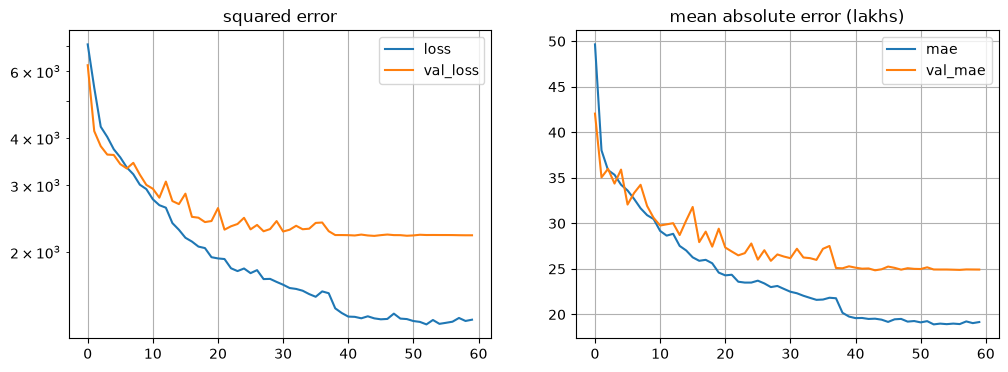

In [15]:
import matplotlib.pyplot as plt

learning_data = pd.DataFrame(price_history.history)

fig, (loss_axis, mae_axis) = plt.subplots(1, 2, figsize=(12, 4))
learning_data[['loss', 'val_loss']].plot(ax=loss_axis, logy=True, grid=True,
                                         title='squared error')
learning_data[['mae', 'val_mae']].plot(ax=mae_axis, grid=True,
                                       title='mean absolute error (lakhs)')
plt.show()

## Evaluating on the held-out listings

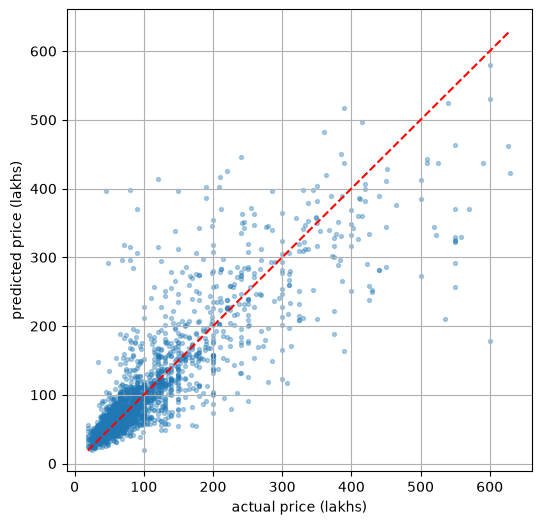

In [16]:
price_predictions = price_model.predict(X_test, verbose=0).ravel()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, price_predictions, s=8, alpha=0.35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('actual price (lakhs)')
plt.ylabel('predicted price (lakhs)')
plt.grid(True)
plt.show()

In [17]:
X_new = X_test[5].reshape(1, -1)

print('actual price     ', round(float(y_test[5]), 2))
print('predicted price  ', round(float(price_model.predict(X_new, verbose=0)[0, 0]), 2))

actual price      65.0
predicted price   60.4


In [18]:
from sklearn.metrics import r2_score

test_scores = price_model.evaluate(X_test, y_test, verbose=0, return_dict=True)

print('House price regressor - test set performance')
print(f"  loss (mse) : {test_scores['loss']:.2f}")
print(f"  rmse       : {np.sqrt(test_scores['loss']):.2f} lakhs")
print(f"  mae        : {test_scores['mae']:.2f} lakhs")
print(f"  r2         : {r2_score(y_test, price_predictions):.4f}")

House price regressor - test set performance
  loss (mse) : 2105.35
  rmse       : 45.88 lakhs
  mae        : 24.78 lakhs
  r2         : 0.7361
